<a href="https://colab.research.google.com/github/Suvanga/-Stable-Roomate/blob/main/MediScan_Beta_Version.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import kagglehub
from pathlib import Path

# Downloading the data set
print(" Downloading MediScan dataset...")

path = kagglehub.dataset_download("khanfashee/nih-chest-x-ray-14-224x224-resized")

print(f" Data ready at: {path}")


dataset_path = Path(path)
image_path = dataset_path / "images"
csv_path = dataset_path / "Data_Entry_2017.csv"

100%|██████████| 2.30G/2.30G [00:20<00:00, 119MB/s]

Extracting files...


 Data ready at: /root/.cache/kagglehub/datasets/khanfashee/nih-chest-x-ray-14-224x224-resized/versions/3


In [2]:
import pandas as pd
import os
from pathlib import Path


dataset_path = Path(path)
image_path = dataset_path / "images"
csv_path = dataset_path / "Data_Entry_2017.csv"


#printinh the images and csv file path location
print(f" Images are here: {image_path}")
print(f" CSV is here: {csv_path}")

if csv_path.exists():
    df = pd.read_csv(csv_path)
    print(f"\n Success! Loaded CSV with {len(df)} rows.")
    print("Here is a preview of the data:")
    print(df[['Image Index', 'Finding Labels']].head(5))
else:
    print("Error: CSV file not found. Check the path.")

 Images are here: /root/.cache/kagglehub/datasets/khanfashee/nih-chest-x-ray-14-224x224-resized/versions/3/images
 CSV is here: /root/.cache/kagglehub/datasets/khanfashee/nih-chest-x-ray-14-224x224-resized/versions/3/Data_Entry_2017.csv

 Success! Loaded CSV with 112120 rows.
Here is a preview of the data:
        Image Index          Finding Labels
0  00000001_000.png            Cardiomegaly
1  00000001_001.png  Cardiomegaly|Emphysema
2  00000001_002.png   Cardiomegaly|Effusion
3  00000002_000.png              No Finding
4  00000003_000.png                  Hernia


In [3]:
import torch
from torch.utils.data import Dataset
from PIL import Image
import os

class ChestXrayDataset(Dataset):
    def __init__(self, dataframe, root_dir, transform=None):
        self.labels_frame = dataframe
        self.root_dir = root_dir
        self.transform = transform

       #classification is going to be done with these labels
        self.all_labels = [
            'Atelectasis', 'Cardiomegaly', 'Effusion', 'Infiltration', 'Mass', 'Nodule',
            'Pneumonia', 'Pneumothorax', 'Consolidation', 'Edema', 'Emphysema',
            'Fibrosis', 'Pleural_Thickening', 'Hernia', 'No Finding'
        ]

    def __len__(self):
        return len(self.labels_frame)

    def __getitem__(self, idx):
        # 1. Get Image Path
        img_name = os.path.join(self.root_dir, self.labels_frame.iloc[idx, 0])
        image = Image.open(img_name).convert('RGB')

        # 2. Get Labels (Multi-Hot Encoding)
        label_str = self.labels_frame.iloc[idx, 1]

        # Check against ALL 15 labels
        label_vec = torch.tensor(
            [1.0 if disease in label_str else 0.0 for disease in self.all_labels],
            dtype=torch.float32
        )

        # 3. Transform
        if self.transform:
            image = self.transform(image)

        return image, label_vec

In [8]:
from torchvision import transforms
from torch.utils.data import DataLoader, random_split

image_path = os.path.join(path, "images-224", "images-224")
# 2. Defining Transforms (Normalizing using ImageNet stats)
data_transforms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

# 3. Creating the Dataset Object instantiating a full_dataset objkect
full_dataset = ChestXrayDataset(
    dataframe=df,
    root_dir=image_path,
    transform=data_transforms
)

# 4. Splitting the dataset into Train (80%) and Test (20%)
train_size = int(0.8 * len(full_dataset))
test_size = len(full_dataset) - train_size
train_dataset, test_dataset = random_split(full_dataset, [train_size, test_size])

# 5. Create DataLoaders for differnet batchsize for backward propagation
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

print(f"  Data Ready!")
print(f"   - Training Images: {len(train_dataset)}")
print(f"   - Testing Images:  {len(test_dataset)}")

# 6. Sanity Check (Force it to load one batch to prove it works)
try:
    images, labels = next(iter(train_loader))
    print(f" SUCCESS! Batch loaded with shape: {images.shape}")
except Exception as e:
    print(f" ERROR: {e}")

  Data Ready!
   - Training Images: 89696
   - Testing Images:  22424
 SUCCESS! Batch loaded with shape: torch.Size([32, 3, 224, 224])


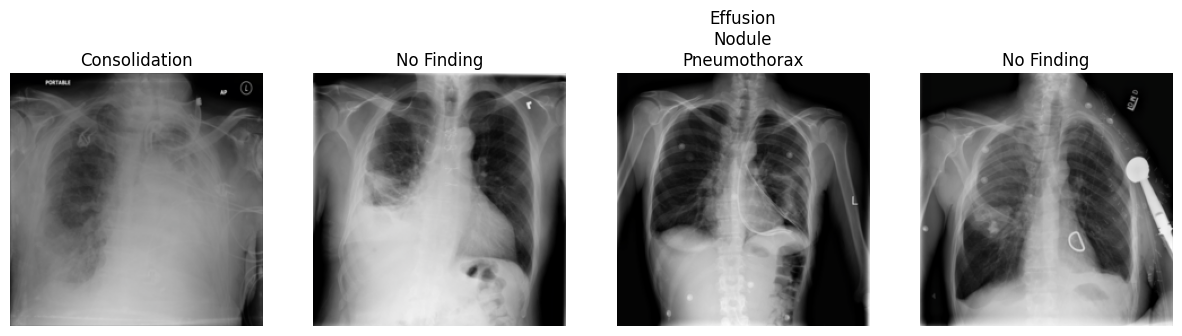

In [27]:
import matplotlib.pyplot as plt
import numpy as np
import torchvision

# 1. Grab a single batch of data
# iter() creates an iterator, next() grabs the first batch
images, labels = next(iter(train_loader))

# 2. Define the list of disease names (for the title)
class_names = [
    'Atelectasis', 'Cardiomegaly', 'Effusion', 'Infiltration', 'Mass', 'Nodule',
    'Pneumonia', 'Pneumothorax', 'Consolidation', 'Edema', 'Emphysema',
    'Fibrosis', 'Pleural_Thickening', 'Hernia', 'No Finding'
]

# 3. Helper function to un-normalize and display
def imshow(inp, title=None):
    """Imshow for Tensor."""
    inp = inp.numpy().transpose((1, 2, 0)) # Convert from (3, 224, 224) to (224, 224, 3)

    # These are the Mean and Std we used in the Transform step
    mean = np.array([0.485, 0.456, 0.406])
    std = np.array([0.229, 0.224, 0.225])

    # Undo the normalization: Image = (Image * Std) + Mean
    inp = std * inp + mean
    inp = np.clip(inp, 0, 1) # Clip values to be between 0 and 1

    plt.imshow(inp)
    if title:
        plt.title(title)
    plt.axis('off')

# 4. Plot a grid of 4 images
plt.figure(figsize=(15, 5))

# We will plot the first 4 images from the batch
for i in range(4):
    ax = plt.subplot(1, 4, i + 1)

    # Get the image and its label
    img = images[i]
    label_vec = labels[i]

    # Convert the label vector (0s and 1s) into a string of diseases
    active_diseases = [class_names[j] for j, val in enumerate(label_vec) if val == 1]
    title = "\n".join(active_diseases) if active_diseases else "No Finding"

    imshow(img, title=title)

plt.show()